In [2]:
# --- QCEW scoping test: verify structure before the full pull ---
#
# I can't reach data.bls.gov from my own environment to test this myself,
# so treat this cell as the real verification step - run it and check
# what actually comes back before we build the full 5-county x 5-year
# historical pull.

import pandas as pd
import requests

NYC_COUNTY_FIPS = {
    "Manhattan (New York County)": "36061",
    "Bronx": "36005",
    "Brooklyn (Kings County)": "36047",
    "Queens": "36081",
    "Staten Island (Richmond County)": "36085",
}

# Quarterly field layout, from the BLS QCEW CSV Data Slices documentation.
QCEW_QUARTERLY_COLUMNS = [
    "area_fips", "own_code", "industry_code", "agglvl_code", "size_code",
    "year", "qtr", "disclosure_code", "qtrly_estabs",
    "month1_emplvl", "month2_emplvl", "month3_emplvl",
    "total_qtrly_wages", "taxable_qtrly_wages", "qtrly_contributions",
    "avg_wkly_wage", "lq_disclosure_code", "lq_qtrly_estabs",
    "lq_month1_emplvl", "lq_month2_emplvl", "lq_month3_emplvl",
    "lq_total_qtrly_wages", "lq_taxable_qtrly_wages", "lq_qtrly_contributions",
    "lq_avg_wkly_wage", "oty_disclosure_code",
    "oty_qtrly_estabs_chg", "oty_qtrly_estabs_pct_chg",
    "oty_month1_emplvl_chg", "oty_month1_emplvl_pct_chg",
    "oty_month2_emplvl_chg", "oty_month2_emplvl_pct_chg",
    "oty_month3_emplvl_chg", "oty_month3_emplvl_pct_chg",
    "oty_total_qtrly_wages_chg", "oty_total_qtrly_wages_pct_chg",
    "oty_taxable_qtrly_wages_chg", "oty_taxable_qtrly_wages_pct_chg",
    "oty_qtrly_contributions_chg", "oty_qtrly_contributions_pct_chg",
    "oty_avg_wkly_wage_chg", "oty_avg_wkly_wage_pct_chg",
]

# Annual-average field layout is shorter (no monthly breakdown).
QCEW_ANNUAL_COLUMNS = [
    "area_fips", "own_code", "industry_code", "agglvl_code", "size_code",
    "year", "qtr", "disclosure_code", "annual_avg_estabs", "annual_avg_emplvl",
    "total_annual_wages", "taxable_annual_wages", "annual_contributions",
    "annual_avg_wkly_wage", "avg_annual_pay", "lq_disclosure_code",
    "lq_annual_avg_estabs", "lq_annual_avg_emplvl", "lq_total_annual_wages",
    "lq_taxable_annual_wages", "lq_annual_contributions", "lq_annual_avg_wkly_wage",
    "lq_avg_annual_pay", "oty_disclosure_code",
    "oty_annual_avg_estabs_chg", "oty_annual_avg_estabs_pct_chg",
    "oty_annual_avg_emplvl_chg", "oty_annual_avg_emplvl_pct_chg",
    "oty_total_annual_wages_chg", "oty_total_annual_wages_pct_chg",
    "oty_taxable_annual_wages_chg", "oty_taxable_annual_wages_pct_chg",
    "oty_annual_contributions_chg", "oty_annual_contributions_pct_chg",
    "oty_annual_avg_wkly_wage_chg", "oty_annual_avg_wkly_wage_pct_chg",
    "oty_avg_annual_pay_chg", "oty_avg_annual_pay_pct_chg",
]


def fetch_qcew_area_slice(year: int, qtr: str, area_fips: str) -> pd.DataFrame:
    """
    qtr: '1'-'4' for a single quarter, or 'a' for annual average.
    Returns a DataFrame with the file's header row used as-is (BLS CSVs
    do include a header row, unlike the quirky exports we've dealt with
    from Airtable/InPlace so far).
    """
    url = f"https://data.bls.gov/cew/data/api/{year}/{qtr}/area/{area_fips}.csv"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    from io import StringIO
    return pd.read_csv(StringIO(resp.text))


# --- Scoping test: one county, one year, annual average ---
TEST_YEAR = 2025  # should be safely published by now
TEST_COUNTY_NAME = "Manhattan (New York County)"
TEST_COUNTY_FIPS = NYC_COUNTY_FIPS[TEST_COUNTY_NAME]

print(f"Pulling {TEST_COUNTY_NAME} ({TEST_COUNTY_FIPS}), {TEST_YEAR} annual average...")
df = fetch_qcew_area_slice(TEST_YEAR, "a", TEST_COUNTY_FIPS)

print(f"\nRows returned: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

print("\nUnique aggregation levels (agglvl_code) present:")
print(df["agglvl_code"].value_counts().sort_index().to_string())

print("\nUnique ownership codes (own_code) present:")
print(df["own_code"].value_counts().sort_index().to_string())

# agglvl_code 74 = County, NAICS Sector, by Ownership (confirmed from the
# actual BLS aggregation-level matrix - county-level codes run 70-78, not
# the national-level 10-19 codes I'd guessed initially). own_code 5 =
# Private ownership - the right slice since internship placements are
# overwhelmingly at private-sector and nonprofit employers (QCEW counts
# nonprofits under Private, not Government).
sector_level = df[(df["agglvl_code"] == 74) & (df["own_code"] == 5)]
print(f"\nSector-level (agglvl_code=74), Private ownership (own_code=5) rows: {len(sector_level)}")
print(sector_level[["industry_code", "annual_avg_estabs", "annual_avg_emplvl", "disclosure_code"]].to_string(index=False))

n_suppressed = (sector_level["disclosure_code"] == "N").sum()
print(f"\nSuppressed (disclosure_code='N') sector-level rows: {n_suppressed} of {len(sector_level)}")
print("If this is 0 or small, sector-level is a safe granularity to use for the full pull.")

Pulling Manhattan (New York County) (36061), 2025 annual average...

Rows returned: 2014
Columns: ['area_fips', 'own_code', 'industry_code', 'agglvl_code', 'size_code', 'year', 'qtr', 'disclosure_code', 'annual_avg_estabs', 'annual_avg_emplvl', 'total_annual_wages', 'taxable_annual_wages', 'annual_contributions', 'annual_avg_wkly_wage', 'avg_annual_pay', 'lq_disclosure_code', 'lq_annual_avg_estabs', 'lq_annual_avg_emplvl', 'lq_total_annual_wages', 'lq_taxable_annual_wages', 'lq_annual_contributions', 'lq_annual_avg_wkly_wage', 'lq_avg_annual_pay', 'oty_disclosure_code', 'oty_annual_avg_estabs_chg', 'oty_annual_avg_estabs_pct_chg', 'oty_annual_avg_emplvl_chg', 'oty_annual_avg_emplvl_pct_chg', 'oty_total_annual_wages_chg', 'oty_total_annual_wages_pct_chg', 'oty_taxable_annual_wages_chg', 'oty_taxable_annual_wages_pct_chg', 'oty_annual_contributions_chg', 'oty_annual_contributions_pct_chg', 'oty_annual_avg_wkly_wage_chg', 'oty_annual_avg_wkly_wage_pct_chg', 'oty_avg_annual_pay_chg', 'oty_

In [3]:
# --- Full QCEW pull: NYC citywide, sector-level, private employment,
#     2022-2025 annual averages ---
#
# Confirmed via the scoping test: agglvl_code=74 (County, NAICS Sector,
# by Ownership) + own_code=5 (Private) gives clean, unsuppressed data for
# all 20 NAICS sectors in Manhattan. Assuming the same holds for the other
# 4 boroughs (checked below, not assumed).
#
# 2026 is deliberately excluded - QCEW annual data needs all 4 quarters,
# and Q4 2026 won't be published until ~5 months after it ends (2027).

import pandas as pd
import requests
import time
from io import StringIO

NYC_COUNTY_FIPS = {
    "Manhattan": "36061",
    "Bronx": "36005",
    "Brooklyn": "36047",
    "Queens": "36081",
    "Staten Island": "36085",
}

YEARS = [2022, 2023, 2024, 2025]  # 2026 excluded - not fully published yet

TARGET_AGGLVL_CODE = 74  # County, NAICS Sector, by Ownership
TARGET_OWN_CODE = 5      # Private

SECONDS_BETWEEN_REQUESTS = 0.5

# Standard 2-digit NAICS sector titles, using QCEW's own sector codes
# (some sectors are combined, e.g. "31-33" for all of Manufacturing).
QCEW_SECTOR_TITLES = {
    "11": "Agriculture, Forestry, Fishing and Hunting",
    "21": "Mining, Quarrying, and Oil and Gas Extraction",
    "22": "Utilities",
    "23": "Construction",
    "31-33": "Manufacturing",
    "42": "Wholesale Trade",
    "44-45": "Retail Trade",
    "48-49": "Transportation and Warehousing",
    "51": "Information",
    "52": "Finance and Insurance",
    "53": "Real Estate and Rental and Leasing",
    "54": "Professional and Technical Services",
    "55": "Management of Companies and Enterprises",
    "56": "Administrative and Waste Services",
    "61": "Educational Services",
    "62": "Health Care and Social Assistance",
    "71": "Arts, Entertainment, and Recreation",
    "72": "Accommodation and Food Services",
    "81": "Other Services (except Public Administration)",
    "92": "Public Administration",
    "99": "Unclassified",
}


def naics_to_qcew_sector(naics_code) -> str:
    """
    Rolls up a (possibly 2-6 digit) NAICS code to the QCEW sector code it
    belongs to, handling the merged sectors (31-33, 44-45, 48-49).
    Use this on your internship opportunities' NAICS Code column to bring
    them to the same granularity as this QCEW pull, for comparison.
    """
    if pd.isna(naics_code):
        return None
    code = str(naics_code).strip()
    prefix2 = code[:2]
    if prefix2 in ("31", "32", "33"):
        return "31-33"
    if prefix2 in ("44", "45"):
        return "44-45"
    if prefix2 in ("48", "49"):
        return "48-49"
    return prefix2


def fetch_qcew_area_slice(year: int, qtr: str, area_fips: str) -> pd.DataFrame:
    url = f"https://data.bls.gov/cew/data/api/{year}/{qtr}/area/{area_fips}.csv"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return pd.read_csv(StringIO(resp.text))


def pull_nyc_sector_data() -> pd.DataFrame:
    all_rows = []
    for year in YEARS:
        for borough, fips in NYC_COUNTY_FIPS.items():
            print(f"Pulling {borough} ({fips}), {year}...")
            df = fetch_qcew_area_slice(year, "a", fips)
            sector = df[(df["agglvl_code"] == TARGET_AGGLVL_CODE) & (df["own_code"] == TARGET_OWN_CODE)].copy()

            n_suppressed = (sector["disclosure_code"] == "N").sum()
            if n_suppressed:
                print(f"  NOTE: {n_suppressed} of {len(sector)} sectors suppressed for {borough} {year}")

            sector["Borough"] = borough
            sector["Cohort Year"] = year
            all_rows.append(sector[["Borough", "Cohort Year", "industry_code",
                                     "annual_avg_estabs", "annual_avg_emplvl",
                                     "avg_annual_pay", "disclosure_code"]])
            time.sleep(SECONDS_BETWEEN_REQUESTS)

    combined = pd.concat(all_rows, ignore_index=True)
    combined = combined.rename(columns={
        "industry_code": "QCEW Sector Code",
        "annual_avg_estabs": "Establishment Count",
        "annual_avg_emplvl": "Average Annual Employment",
        "avg_annual_pay": "Average Annual Pay",
        "disclosure_code": "Disclosure Code",
    })
    combined["QCEW Sector Title"] = combined["QCEW Sector Code"].map(QCEW_SECTOR_TITLES)
    return combined


def aggregate_to_citywide(borough_level: pd.DataFrame) -> pd.DataFrame:
    """
    Sums employment and establishment counts across the 5 boroughs to get
    a single NYC citywide number per sector per year. Average Annual Pay
    can't just be summed or averaged across boroughs without weighting by
    employment, so it's dropped at this level - use the borough-level file
    if per-borough pay comparisons matter.
    """
    citywide = (
        borough_level.groupby(["Cohort Year", "QCEW Sector Code", "QCEW Sector Title"])
        .agg(
            Total_NYC_Establishment_Count=("Establishment Count", "sum"),
            Total_NYC_Average_Annual_Employment=("Average Annual Employment", "sum"),
            Boroughs_Suppressed=("Disclosure Code", lambda s: (s == "N").sum()),
        )
        .reset_index()
    )
    total_per_year = citywide.groupby("Cohort Year")["Total_NYC_Average_Annual_Employment"].transform("sum")
    citywide["Pct_Of_NYC_Total_Employment"] = (
        citywide["Total_NYC_Average_Annual_Employment"] / total_per_year * 100
    ).round(2)
    return citywide.sort_values(["Cohort Year", "Total_NYC_Average_Annual_Employment"], ascending=[True, False])


# --- Run the full pull ---
borough_level = pull_nyc_sector_data()
borough_level.to_csv("../../data/qcew_nyc_sector_by_borough.csv", index=False)
print(f"\nWrote ../../data/qcew_nyc_sector_by_borough.csv ({len(borough_level)} rows)")

citywide = aggregate_to_citywide(borough_level)
citywide.to_csv("../../data/qcew_nyc_sector_citywide.csv", index=False)
print(f"Wrote ../../data/qcew_nyc_sector_citywide.csv ({len(citywide)} rows)")

n_any_suppressed = (citywide["Boroughs_Suppressed"] > 0).sum()
print(f"\nSector-years with at least one borough suppressed: {n_any_suppressed} of {len(citywide)}")

print("\nCitywide employment by sector, most recent year available:")
latest_year = citywide["Cohort Year"].max()
print(citywide[citywide["Cohort Year"] == latest_year]
      [["QCEW Sector Title", "Total_NYC_Average_Annual_Employment", "Pct_Of_NYC_Total_Employment"]]
      .to_string(index=False))

Pulling Manhattan (36061), 2022...
Pulling Bronx (36005), 2022...
  NOTE: 4 of 20 sectors suppressed for Bronx 2022
Pulling Brooklyn (36047), 2022...
Pulling Queens (36081), 2022...
Pulling Staten Island (36085), 2022...
Pulling Manhattan (36061), 2023...
Pulling Bronx (36005), 2023...
  NOTE: 4 of 20 sectors suppressed for Bronx 2023
Pulling Brooklyn (36047), 2023...
Pulling Queens (36081), 2023...
Pulling Staten Island (36085), 2023...
  NOTE: 2 of 19 sectors suppressed for Staten Island 2023
Pulling Manhattan (36061), 2024...
Pulling Bronx (36005), 2024...
  NOTE: 4 of 20 sectors suppressed for Bronx 2024
Pulling Brooklyn (36047), 2024...
Pulling Queens (36081), 2024...
Pulling Staten Island (36085), 2024...
  NOTE: 2 of 19 sectors suppressed for Staten Island 2024
Pulling Manhattan (36061), 2025...
Pulling Bronx (36005), 2025...
  NOTE: 4 of 20 sectors suppressed for Bronx 2025
Pulling Brooklyn (36047), 2025...
Pulling Queens (36081), 2025...
Pulling Staten Island (36085), 2025...


In [5]:
# --- Full QCEW pull: NYC citywide, sector-level, private employment,
#     2022-2025 annual averages ---
#
# Confirmed via the scoping test: agglvl_code=74 (County, NAICS Sector,
# by Ownership) + own_code=5 (Private) gives clean, unsuppressed data for
# all 20 NAICS sectors in Manhattan. Assuming the same holds for the other
# 4 boroughs (checked below, not assumed).
#
# 2026 is deliberately excluded - QCEW annual data needs all 4 quarters,
# and Q4 2026 won't be published until ~5 months after it ends (2027).

import pandas as pd
import requests
import time
from io import StringIO

NYC_COUNTY_FIPS = {
    "Manhattan": "36061",
    "Bronx": "36005",
    "Brooklyn": "36047",
    "Queens": "36081",
    "Staten Island": "36085",
}

YEARS = [2022, 2023, 2024, 2025]  # 2026 excluded - not fully published yet

TARGET_AGGLVL_CODE = 74  # County, NAICS Sector, by Ownership
TARGET_OWN_CODE = 5      # Private

SECONDS_BETWEEN_REQUESTS = 0.5

# Standard 2-digit NAICS sector titles, using QCEW's own sector codes
# (some sectors are combined, e.g. "31-33" for all of Manufacturing).
QCEW_SECTOR_TITLES = {
    "11": "Agriculture, Forestry, Fishing and Hunting",
    "21": "Mining, Quarrying, and Oil and Gas Extraction",
    "22": "Utilities",
    "23": "Construction",
    "31-33": "Manufacturing",
    "42": "Wholesale Trade",
    "44-45": "Retail Trade",
    "48-49": "Transportation and Warehousing",
    "51": "Information",
    "52": "Finance and Insurance",
    "53": "Real Estate and Rental and Leasing",
    "54": "Professional and Technical Services",
    "55": "Management of Companies and Enterprises",
    "56": "Administrative and Waste Services",
    "61": "Educational Services",
    "62": "Health Care and Social Assistance",
    "71": "Arts, Entertainment, and Recreation",
    "72": "Accommodation and Food Services",
    "81": "Other Services (except Public Administration)",
    "92": "Public Administration",
    "99": "Unclassified",
}


def naics_to_qcew_sector(naics_code) -> str:
    """
    Rolls up a (possibly 2-6 digit) NAICS code to the QCEW sector code it
    belongs to, handling the merged sectors (31-33, 44-45, 48-49).
    Use this on your internship opportunities' NAICS Code column to bring
    them to the same granularity as this QCEW pull, for comparison.
    """
    if pd.isna(naics_code):
        return None
    code = str(naics_code).strip()
    prefix2 = code[:2]
    if prefix2 in ("31", "32", "33"):
        return "31-33"
    if prefix2 in ("44", "45"):
        return "44-45"
    if prefix2 in ("48", "49"):
        return "48-49"
    return prefix2


def fetch_qcew_area_slice(year: int, qtr: str, area_fips: str) -> pd.DataFrame:
    url = f"https://data.bls.gov/cew/data/api/{year}/{qtr}/area/{area_fips}.csv"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return pd.read_csv(StringIO(resp.text))


def pull_nyc_sector_data() -> pd.DataFrame:
    all_rows = []
    for year in YEARS:
        for borough, fips in NYC_COUNTY_FIPS.items():
            print(f"Pulling {borough} ({fips}), {year}...")
            df = fetch_qcew_area_slice(year, "a", fips)
            sector = df[(df["agglvl_code"] == TARGET_AGGLVL_CODE) & (df["own_code"] == TARGET_OWN_CODE)].copy()

            n_suppressed = (sector["disclosure_code"] == "N").sum()
            if n_suppressed:
                print(f"  NOTE: {n_suppressed} of {len(sector)} sectors suppressed for {borough} {year}")

            sector["Borough"] = borough
            sector["Cohort Year"] = year
            all_rows.append(sector[["Borough", "Cohort Year", "industry_code",
                                     "annual_avg_estabs", "annual_avg_emplvl",
                                     "avg_annual_pay", "disclosure_code"]])
            time.sleep(SECONDS_BETWEEN_REQUESTS)

    combined = pd.concat(all_rows, ignore_index=True)
    combined = combined.rename(columns={
        "industry_code": "QCEW Sector Code",
        "annual_avg_estabs": "Establishment Count",
        "annual_avg_emplvl": "Average Annual Employment",
        "avg_annual_pay": "Average Annual Pay",
        "disclosure_code": "Disclosure Code",
    })
    combined["QCEW Sector Title"] = combined["QCEW Sector Code"].map(QCEW_SECTOR_TITLES)
    return combined


def aggregate_to_citywide(borough_level: pd.DataFrame) -> pd.DataFrame:
    """
    Sums employment and establishment counts across the 5 boroughs to get
    a single NYC citywide number per sector per year. Average Annual Pay
    can't just be summed or averaged across boroughs without weighting by
    employment, so it's dropped at this level - use the borough-level file
    if per-borough pay comparisons matter.
    """
    citywide = (
        borough_level.groupby(["Cohort Year", "QCEW Sector Code", "QCEW Sector Title"])
        .agg(
            Total_NYC_Establishment_Count=("Establishment Count", "sum"),
            Total_NYC_Average_Annual_Employment=("Average Annual Employment", "sum"),
            Boroughs_Suppressed=("Disclosure Code", lambda s: (s == "N").sum()),
        )
        .reset_index()
    )
    total_per_year = citywide.groupby("Cohort Year")["Total_NYC_Average_Annual_Employment"].transform("sum")
    citywide["Pct_Of_NYC_Total_Employment"] = (
        citywide["Total_NYC_Average_Annual_Employment"] / total_per_year * 100
    ).round(2)
    citywide["Contains Suppressed Borough Data"] = citywide["Boroughs_Suppressed"] > 0
    return citywide.sort_values(["Cohort Year", "Total_NYC_Average_Annual_Employment"], ascending=[True, False])


# --- Run the full pull ---
borough_level = pull_nyc_sector_data()
borough_level.to_csv("../../data/qcew_nyc_sector_by_borough.csv", index=False)
print(f"\nWrote ../../data/qcew_nyc_sector_by_borough.csv ({len(borough_level)} rows)")

citywide = aggregate_to_citywide(borough_level)
citywide.to_csv("../../data/qcew_nyc_sector_citywide.csv", index=False)
print(f"Wrote ../../data/qcew_nyc_sector_citywide.csv ({len(citywide)} rows)")

n_any_suppressed = (citywide["Boroughs_Suppressed"] > 0).sum()
print(f"\nSector-years with at least one borough suppressed: {n_any_suppressed} of {len(citywide)}")

print("\nCitywide employment by sector, most recent year available:")
latest_year = citywide["Cohort Year"].max()
print(citywide[citywide["Cohort Year"] == latest_year]
      [["QCEW Sector Title", "Total_NYC_Average_Annual_Employment", "Pct_Of_NYC_Total_Employment"]]
      .to_string(index=False))

Pulling Manhattan (36061), 2022...
Pulling Bronx (36005), 2022...
  NOTE: 4 of 20 sectors suppressed for Bronx 2022
Pulling Brooklyn (36047), 2022...
Pulling Queens (36081), 2022...
Pulling Staten Island (36085), 2022...
Pulling Manhattan (36061), 2023...
Pulling Bronx (36005), 2023...
  NOTE: 4 of 20 sectors suppressed for Bronx 2023
Pulling Brooklyn (36047), 2023...
Pulling Queens (36081), 2023...
Pulling Staten Island (36085), 2023...
  NOTE: 2 of 19 sectors suppressed for Staten Island 2023
Pulling Manhattan (36061), 2024...
Pulling Bronx (36005), 2024...
  NOTE: 4 of 20 sectors suppressed for Bronx 2024
Pulling Brooklyn (36047), 2024...
Pulling Queens (36081), 2024...
Pulling Staten Island (36085), 2024...
  NOTE: 2 of 19 sectors suppressed for Staten Island 2024
Pulling Manhattan (36061), 2025...
Pulling Bronx (36005), 2025...
  NOTE: 4 of 20 sectors suppressed for Bronx 2025
Pulling Brooklyn (36047), 2025...
Pulling Queens (36081), 2025...
Pulling Staten Island (36085), 2025...


Dropped 438 insufficient-information rows (6.4%)
Filtered to Bachelor's-or-higher placements only: kept 3870 of 6378 (60.7%)
NOTE: this comparison now reflects degree-requiring occupations only, per the college-internship-program framing - not the full placement mix.
Wrote ../../data/internal_sector_mix_by_year.csv (76 rows)
Wrote ../../data/internal_vs_citywide_comparison.csv (76 rows)

Years with both internal and citywide data: [2022, 2023, 2024, 2025]
2026 internal data has no citywide comparison yet (QCEW not published for 2026).


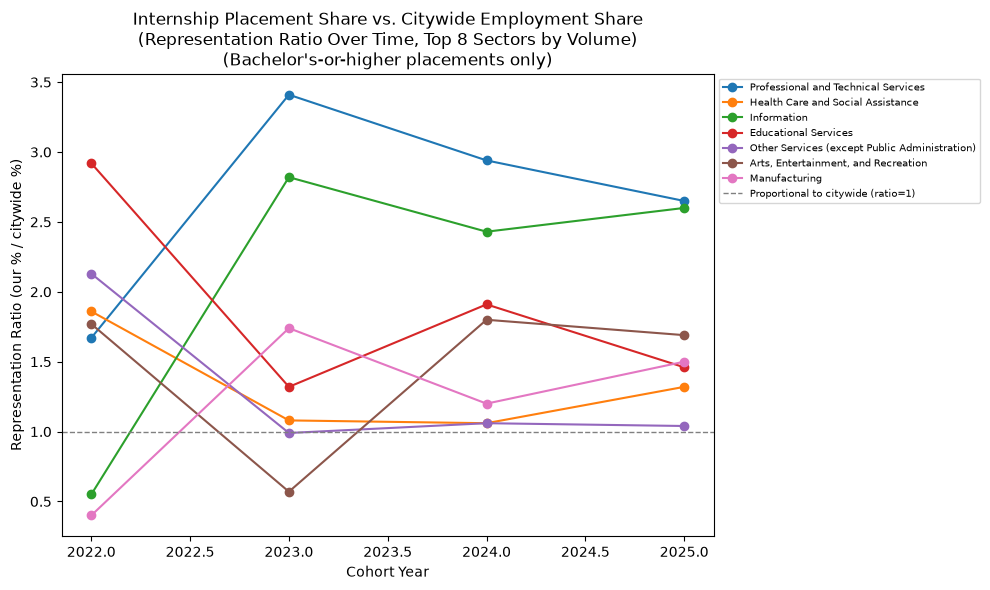

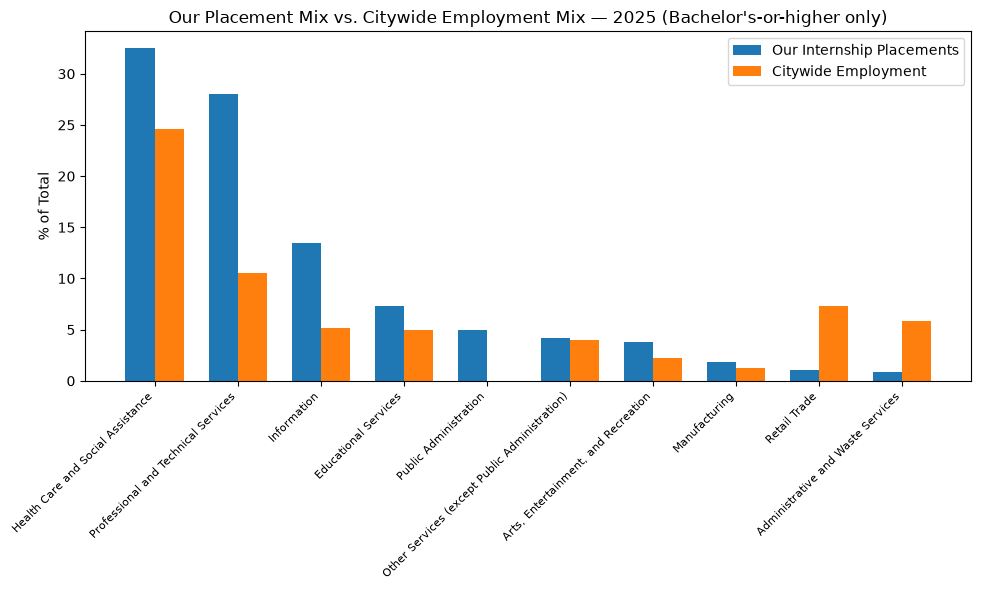

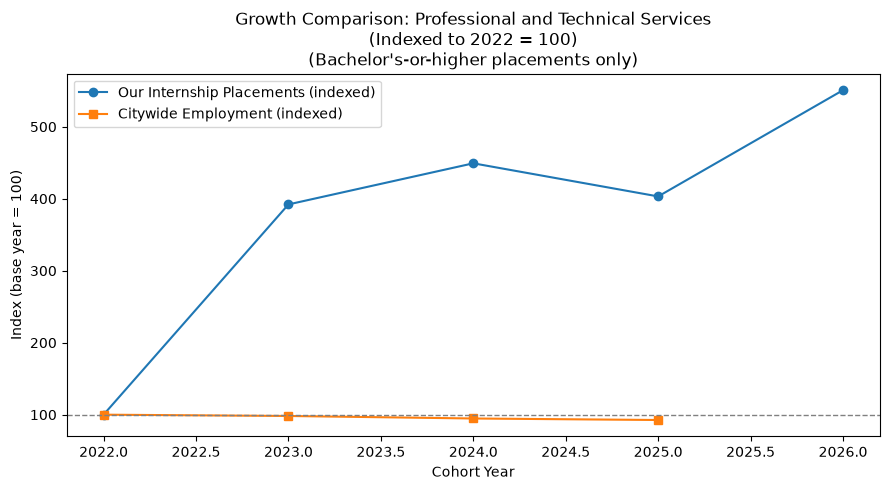


Tidy CSVs and charts written to ../../data/


In [10]:
# --- Internal internship sector mix vs. citywide QCEW employment mix,
#     over time ---
#
# This is the actual comparison the project has been building toward:
# are we placing students into sectors roughly proportional to how those
# sectors exist/grow in NYC's economy, or are we over/under-indexed
# somewhere?
#
# Note on years: our internship data (AllRoles_nioccs_coded.csv) covers
# 2022-2026. QCEW only goes through 2025 (2026 isn't fully published yet -
# see the earlier note on QCEW's ~5-month publication lag). So the
# side-by-side comparison below is necessarily 2022-2025; 2026 shows up
# only in the internal-only view, with nothing to compare it against yet.

import pandas as pd
import matplotlib.pyplot as plt

READY_PATH = "../../data/AllRoles_nioccs_ready.csv"
CODED_PATH = "../../data/AllRoles_nioccs_coded_with_education.csv"
CITYWIDE_PATH = "../../data/qcew_nyc_sector_citywide.csv"

DROP_INSUFFICIENT_ROWS = True  # matches the convention from rawcounts_charts

# New: restrict to placements typically requiring a Bachelor's degree or
# higher, since this is a college internship program - a citywide
# comparison that includes e.g. retail cashier or warehouse roles isn't
# answering the question this project actually cares about. Set to False
# to go back to the full (all-education-levels) comparison.
REQUIRE_BACHELORS_OR_HIGHER = True

QCEW_SECTOR_TITLES = {
    "11": "Agriculture, Forestry, Fishing and Hunting", "21": "Mining, Quarrying, and Oil and Gas Extraction",
    "22": "Utilities", "23": "Construction", "31-33": "Manufacturing", "42": "Wholesale Trade",
    "44-45": "Retail Trade", "48-49": "Transportation and Warehousing", "51": "Information",
    "52": "Finance and Insurance", "53": "Real Estate and Rental and Leasing",
    "54": "Professional and Technical Services", "55": "Management of Companies and Enterprises",
    "56": "Administrative and Waste Services", "61": "Educational Services",
    "62": "Health Care and Social Assistance", "71": "Arts, Entertainment, and Recreation",
    "72": "Accommodation and Food Services", "81": "Other Services (except Public Administration)",
    "92": "Public Administration", "99": "Unclassified",
}


def naics_to_qcew_sector(naics_code) -> str:
    if pd.isna(naics_code):
        return None
    code = str(naics_code).strip()
    prefix2 = code[:2]
    if prefix2 in ("31", "32", "33"):
        return "31-33"
    if prefix2 in ("44", "45"):
        return "44-45"
    if prefix2 in ("48", "49"):
        return "48-49"
    return prefix2


# ------------------------------------------------------------------
# Build the internal (internship) side: % of placements per QCEW sector,
# per cohort year - student-weighted, successfully coded rows only.
# ------------------------------------------------------------------
ready = pd.read_csv(READY_PATH, encoding="utf-8-sig")
coded = pd.read_csv(CODED_PATH, encoding="utf-8-sig")

merged = coded.merge(ready[["Opportunity Identifier", "Cohort Year"]], on="Opportunity Identifier", how="left")
merged = merged.dropna(subset=["Cohort Year"])
merged = merged[merged["API Call Error"].isna()]
merged["Cohort Year"] = merged["Cohort Year"].astype(int)

if DROP_INSUFFICIENT_ROWS:
    before = len(merged)
    merged = merged[
        ~(merged["SOC Flagged As Insufficient Information"] | merged["NAICS Flagged As Insufficient Information"])
    ]
    print(f"Dropped {before - len(merged)} insufficient-information rows ({(before - len(merged)) / before * 100:.1f}%)")

if REQUIRE_BACHELORS_OR_HIGHER:
    before = len(merged)
    merged = merged[merged["Requires Bachelors Or Higher"] == True]
    print(f"Filtered to Bachelor's-or-higher placements only: kept {len(merged)} of {before} "
          f"({len(merged) / before * 100:.1f}%)")
    print("NOTE: this comparison now reflects degree-requiring occupations only, per the "
          "college-internship-program framing - not the full placement mix.")

merged["QCEW Sector Code"] = merged["NAICS Code"].apply(naics_to_qcew_sector)
merged["QCEW Sector Title"] = merged["QCEW Sector Code"].map(QCEW_SECTOR_TITLES)

internal_counts = merged.groupby(["Cohort Year", "QCEW Sector Code", "QCEW Sector Title"]).size().rename("Internal_Placement_Count").reset_index()
internal_totals = internal_counts.groupby("Cohort Year")["Internal_Placement_Count"].transform("sum")
internal_counts["Pct_Of_Internal_Placements"] = (internal_counts["Internal_Placement_Count"] / internal_totals * 100).round(2)

internal_counts.to_csv("../../data/internal_sector_mix_by_year.csv", index=False)
print(f"Wrote ../../data/internal_sector_mix_by_year.csv ({len(internal_counts)} rows)")

# ------------------------------------------------------------------
# Load citywide side and join on (Cohort Year, QCEW Sector Code)
# ------------------------------------------------------------------
citywide = pd.read_csv(CITYWIDE_PATH)
citywide["QCEW Sector Code"] = citywide["QCEW Sector Code"].astype(str)
internal_counts["QCEW Sector Code"] = internal_counts["QCEW Sector Code"].astype(str)

comparison = internal_counts.merge(
    citywide[["Cohort Year", "QCEW Sector Code", "Pct_Of_NYC_Total_Employment", "Contains Suppressed Borough Data"]],
    on=["Cohort Year", "QCEW Sector Code"],
    how="left",  # keep internal-only rows (e.g. 2026) even with no citywide match
)
comparison["Representation_Ratio"] = (
    comparison["Pct_Of_Internal_Placements"] / comparison["Pct_Of_NYC_Total_Employment"]
).round(2)

comparison.to_csv("../../data/internal_vs_citywide_comparison.csv", index=False)
print(f"Wrote ../../data/internal_vs_citywide_comparison.csv ({len(comparison)} rows)")

overlap_years = sorted(set(comparison["Cohort Year"]) & set(citywide["Cohort Year"]))
print(f"\nYears with both internal and citywide data: {overlap_years}")
print(f"2026 internal data has no citywide comparison yet (QCEW not published for 2026).")

# ------------------------------------------------------------------
# Chart 1: Representation ratio over time, top sectors by internal volume
# Ratio > 1 = we place MORE than citywide employment share would suggest.
# Ratio < 1 = we place LESS than citywide employment share would suggest.
# ------------------------------------------------------------------
top_sectors = (
    internal_counts.groupby("QCEW Sector Title")["Internal_Placement_Count"].sum()
    .sort_values(ascending=False).head(8).index.tolist()
)

overlap_data = comparison[comparison["Cohort Year"].isin(overlap_years)]

fig, ax = plt.subplots(figsize=(10, 6))
for sector in top_sectors:
    s = overlap_data[overlap_data["QCEW Sector Title"] == sector].sort_values("Cohort Year")
    if s["Representation_Ratio"].notna().any():
        ax.plot(s["Cohort Year"], s["Representation_Ratio"], marker="o", label=sector)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Proportional to citywide (ratio=1)")
ax.set_title("Internship Placement Share vs. Citywide Employment Share\n(Representation Ratio Over Time, Top 8 Sectors by Volume)"
             + ("\n(Bachelor's-or-higher placements only)" if REQUIRE_BACHELORS_OR_HIGHER else ""))
ax.set_xlabel("Cohort Year")
ax.set_ylabel("Representation Ratio (our % / citywide %)")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.savefig("../../data/representation_ratio_over_time.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# Chart 2: Side-by-side bars, our % vs citywide %, most recent overlap year
# ------------------------------------------------------------------
latest_overlap_year = max(overlap_years)
latest = overlap_data[overlap_data["Cohort Year"] == latest_overlap_year].sort_values(
    "Pct_Of_Internal_Placements", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(latest))
width = 0.35
ax.bar([i - width / 2 for i in x], latest["Pct_Of_Internal_Placements"], width, label="Our Internship Placements")
ax.bar([i + width / 2 for i in x], latest["Pct_Of_NYC_Total_Employment"], width, label="Citywide Employment")
ax.set_xticks(list(x))
ax.set_xticklabels(latest["QCEW Sector Title"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% of Total")
ax.set_title(f"Our Placement Mix vs. Citywide Employment Mix — {latest_overlap_year}"
             + (" (Bachelor's-or-higher only)" if REQUIRE_BACHELORS_OR_HIGHER else ""))
ax.legend()
plt.tight_layout()
plt.savefig("../../data/placement_vs_citywide_latest_year.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# Chart 3: Growth trend - indexed to first available year = 100 - for our
# placements vs citywide employment, in the top sector by internal volume
# ------------------------------------------------------------------
top_sector = top_sectors[0]
top_sector_data = comparison[comparison["QCEW Sector Title"] == top_sector].sort_values("Cohort Year")

base_internal = top_sector_data["Internal_Placement_Count"].iloc[0]
top_sector_data = top_sector_data.copy()
top_sector_data["Internal_Index"] = (top_sector_data["Internal_Placement_Count"] / base_internal * 100).round(1)

overlap_only = top_sector_data[top_sector_data["Cohort Year"].isin(overlap_years)]
base_citywide = overlap_only["Pct_Of_NYC_Total_Employment"].iloc[0]
top_sector_data.loc[top_sector_data["Cohort Year"].isin(overlap_years), "Citywide_Index"] = (
    overlap_only["Pct_Of_NYC_Total_Employment"] / base_citywide * 100
).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(top_sector_data["Cohort Year"], top_sector_data["Internal_Index"], marker="o", label="Our Internship Placements (indexed)")
ax.plot(top_sector_data["Cohort Year"], top_sector_data["Citywide_Index"], marker="s", label="Citywide Employment (indexed)")
ax.axhline(100, color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Growth Comparison: {top_sector}\n(Indexed to {overlap_years[0]} = 100)"
             + ("\n(Bachelor's-or-higher placements only)" if REQUIRE_BACHELORS_OR_HIGHER else ""))
ax.set_xlabel("Cohort Year")
ax.set_ylabel("Index (base year = 100)")
ax.legend()
plt.tight_layout()
plt.savefig("../../data/growth_index_top_sector.png", dpi=150)
plt.show()

print("\nTidy CSVs and charts written to ../../data/")

Growth window: 2022 -> 2025

Citywide employment growth by sector, 2022 -> 2025:
                            QCEW Sector Title  Citywide_Pct_Growth
               Transportation and Warehousing                 41.1
            Health Care and Social Assistance                 19.3
      Management of Companies and Enterprises                 17.9
Mining, Quarrying, and Oil and Gas Extraction                 17.7
          Arts, Entertainment, and Recreation                 16.9
                                    Utilities                 16.0
              Accommodation and Food Services                 12.4
                         Educational Services                  7.6
                        Finance and Insurance                  6.7
                                 Unclassified                  5.8
            Administrative and Waste Services                  2.5
Other Services (except Public Administration)                  1.8
           Real Estate and Rental and Leasing   

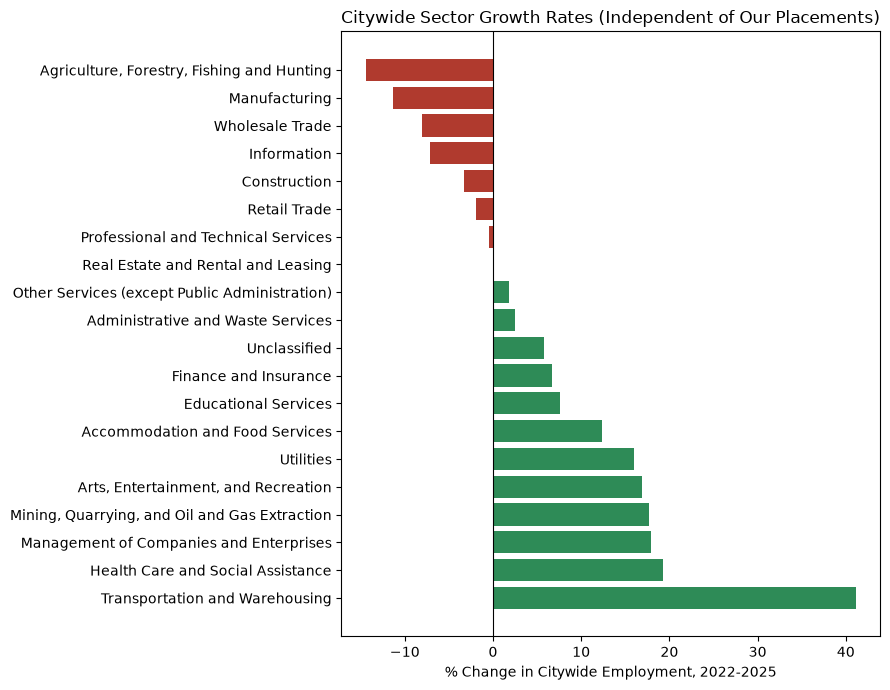


Growth-vs-representation quadrant data (median growth=5.8%, median ratio=0.15), excluding {'Agriculture, Forestry, Fishing and Hunting'}:
                                               Citywide_Pct_Growth  Representation_Ratio_Latest  Our_Placement_Volume_Latest
QCEW Sector Title                                                                                                           
Transportation and Warehousing                                41.1                         0.00                          0.0
Health Care and Social Assistance                             19.3                         1.32                        295.0
Management of Companies and Enterprises                       17.9                         0.06                          1.0
Mining, Quarrying, and Oil and Gas Extraction                 17.7                         0.00                          0.0
Arts, Entertainment, and Recreation                           16.9                         1.69                

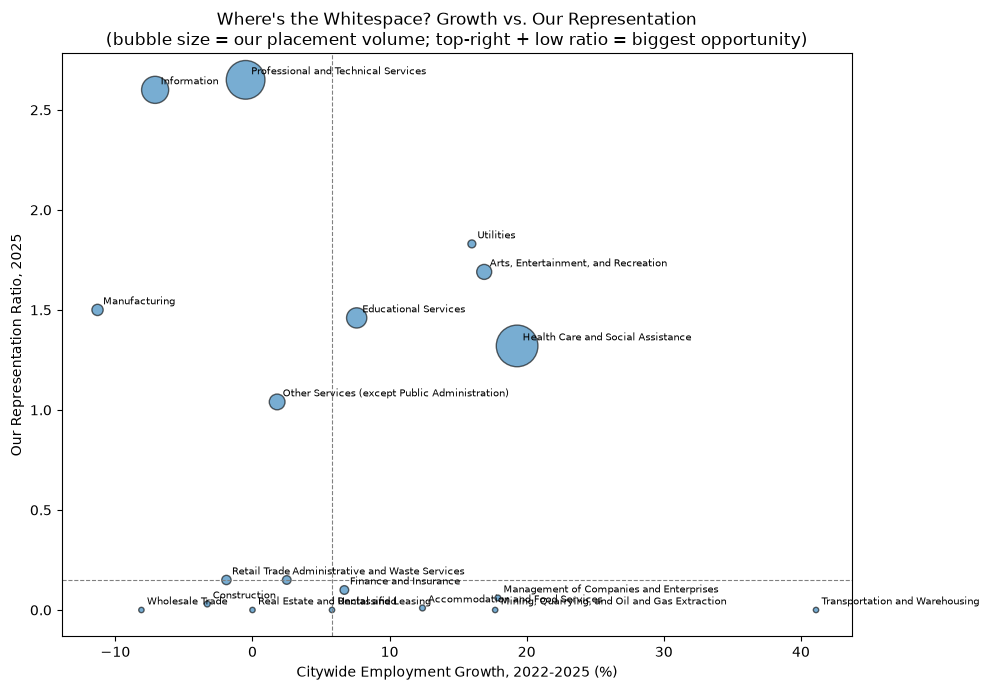

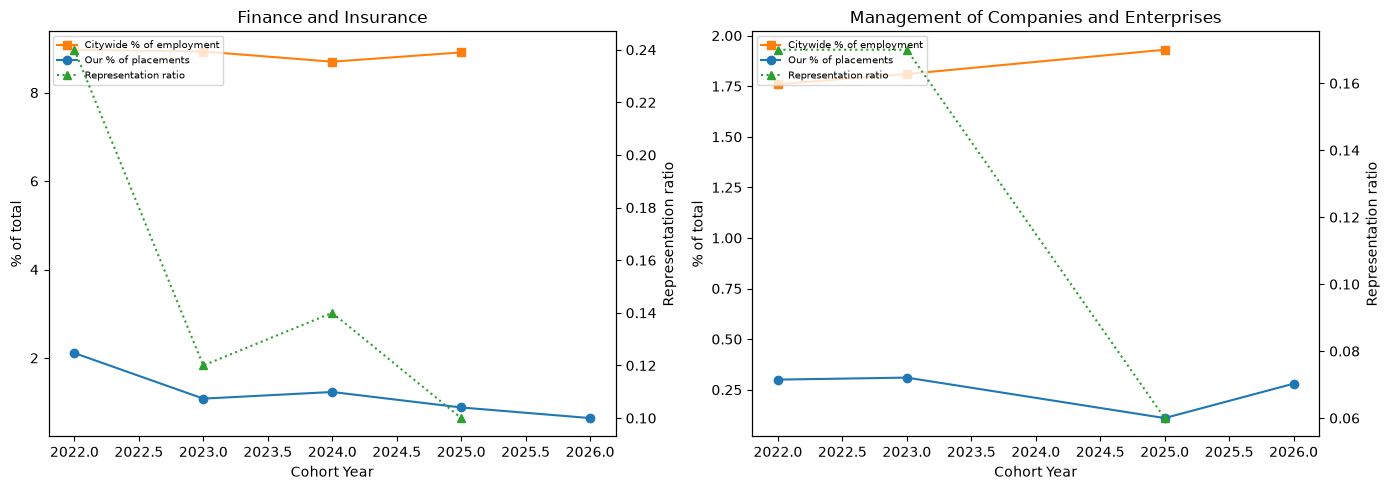


All outputs written to ../../data/ - paste back the printed tables and I'll help interpret.


In [11]:
# --- Exploration round 2: where should we consider growing? ---
#
# Three new cuts, none of which just repeat the representation-ratio view:
#   1. Citywide sector growth rates on their own (independent of us) -
#      which sectors are genuinely booming in NYC right now.
#   2. A growth-vs-representation quadrant: citywide growth rate (x) vs
#      our representation ratio (y), bubble size = our placement volume.
#      This is the "where's the whitespace" chart - big bubbles low on
#      the y-axis but far right on the x-axis are underexploited growth.
#   3. A named deep-dive on Finance and Insurance (your hunch) plus
#      whatever else surfaces as a top quadrant candidate, tracking all
#      three series (citywide employment, our placements, representation
#      ratio) together over time.

import pandas as pd
import matplotlib.pyplot as plt

COMPARISON_PATH = "../../data/internal_vs_citywide_comparison.csv"
CITYWIDE_PATH = "../../data/qcew_nyc_sector_citywide.csv"

comparison = pd.read_csv(COMPARISON_PATH)
citywide = pd.read_csv(CITYWIDE_PATH)

overlap_years = sorted(set(comparison["Cohort Year"]) & set(citywide["Cohort Year"]))
first_year, last_year = min(overlap_years), max(overlap_years)
print(f"Growth window: {first_year} -> {last_year}")

# ------------------------------------------------------------------
# 1. Citywide sector growth rates, independent of us
# ------------------------------------------------------------------
citywide_first = citywide[citywide["Cohort Year"] == first_year].set_index("QCEW Sector Title")["Total_NYC_Average_Annual_Employment"]
citywide_last = citywide[citywide["Cohort Year"] == last_year].set_index("QCEW Sector Title")["Total_NYC_Average_Annual_Employment"]
citywide_growth = ((citywide_last - citywide_first) / citywide_first * 100).round(1).rename("Citywide_Pct_Growth").reset_index()
citywide_growth = citywide_growth.sort_values("Citywide_Pct_Growth", ascending=False)
citywide_growth.to_csv("../../data/citywide_sector_growth_rates.csv", index=False)

print(f"\nCitywide employment growth by sector, {first_year} -> {last_year}:")
print(citywide_growth.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#2E8B57" if v >= 0 else "#B03A2E" for v in citywide_growth["Citywide_Pct_Growth"]]
ax.barh(citywide_growth["QCEW Sector Title"], citywide_growth["Citywide_Pct_Growth"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"% Change in Citywide Employment, {first_year}-{last_year}")
ax.set_title("Citywide Sector Growth Rates (Independent of Our Placements)")
plt.tight_layout()
plt.savefig("../../data/citywide_growth_rates.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 2. Growth-vs-representation quadrant
# ------------------------------------------------------------------
# Agriculture, Forestry, Fishing and Hunting is excluded here - it's such
# a tiny sector in NYC that small absolute changes produce huge % swings,
# which stretches the x-axis and hides the detail among sectors that
# actually matter for this analysis. Excluded from the chart AND the
# opportunity-detection logic below, since a median/plot including it
# would be distorted by the same noise.
EXCLUDED_FROM_QUADRANT = {"Agriculture, Forestry, Fishing and Hunting"}

our_first = comparison[comparison["Cohort Year"] == first_year].set_index("QCEW Sector Title")
our_last = comparison[comparison["Cohort Year"] == last_year].set_index("QCEW Sector Title")

quadrant = pd.DataFrame({
    "Citywide_Pct_Growth": citywide_growth.set_index("QCEW Sector Title")["Citywide_Pct_Growth"],
    "Representation_Ratio_Latest": our_last["Representation_Ratio"],
    "Our_Placement_Volume_Latest": our_last["Internal_Placement_Count"],
}).dropna(subset=["Citywide_Pct_Growth"])
quadrant["Our_Placement_Volume_Latest"] = quadrant["Our_Placement_Volume_Latest"].fillna(0)
quadrant["Representation_Ratio_Latest"] = quadrant["Representation_Ratio_Latest"].fillna(0)
quadrant = quadrant.drop(index=[s for s in EXCLUDED_FROM_QUADRANT if s in quadrant.index])
quadrant.to_csv("../../data/growth_vs_representation_quadrant.csv")

median_growth = quadrant["Citywide_Pct_Growth"].median()
median_ratio = quadrant["Representation_Ratio_Latest"].median()

print(f"\nGrowth-vs-representation quadrant data (median growth={median_growth:.1f}%, "
      f"median ratio={median_ratio:.2f}), excluding {EXCLUDED_FROM_QUADRANT}:")
print(quadrant.sort_values("Citywide_Pct_Growth", ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
sizes = (quadrant["Our_Placement_Volume_Latest"] + 5) * 3  # +5 floor so zero-volume sectors still show as a dot
scatter = ax.scatter(quadrant["Citywide_Pct_Growth"], quadrant["Representation_Ratio_Latest"],
                      s=sizes, alpha=0.6, edgecolors="black")
for title, row in quadrant.iterrows():
    ax.annotate(title, (row["Citywide_Pct_Growth"], row["Representation_Ratio_Latest"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axvline(median_growth, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(median_ratio, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"Citywide Employment Growth, {first_year}-{last_year} (%)")
ax.set_ylabel(f"Our Representation Ratio, {last_year}")
ax.set_title("Where's the Whitespace? Growth vs. Our Representation\n(bubble size = our placement volume; top-right + low ratio = biggest opportunity)")
plt.tight_layout()
plt.savefig("../../data/growth_vs_representation_quadrant.png", dpi=150)
plt.show()
# ------------------------------------------------------------------
# 3. Named deep-dive: Finance and Insurance, plus top quadrant candidate
# ------------------------------------------------------------------
deep_dive_sectors = ["Finance and Insurance"]
if len(opportunity_sectors):
    top_candidate = opportunity_sectors.index[0]
    if top_candidate not in deep_dive_sectors:
        deep_dive_sectors.append(top_candidate)
elif len(zero_presence_growing):
    # fall back to the top zero-presence growing sector if no active-sector candidate exists
    top_candidate = zero_presence_growing.index[0]
    if top_candidate not in deep_dive_sectors:
        deep_dive_sectors.append(top_candidate)

fig, axes = plt.subplots(1, len(deep_dive_sectors), figsize=(7 * len(deep_dive_sectors), 5), squeeze=False)
for i, sector in enumerate(deep_dive_sectors):
    ax = axes[0][i]
    sector_data = comparison[comparison["QCEW Sector Title"] == sector].sort_values("Cohort Year")
    ax2 = ax.twinx()
    ax.plot(sector_data["Cohort Year"], sector_data["Pct_Of_NYC_Total_Employment"], marker="s", color="tab:orange", label="Citywide % of employment")
    ax.plot(sector_data["Cohort Year"], sector_data["Pct_Of_Internal_Placements"], marker="o", color="tab:blue", label="Our % of placements")
    ax2.plot(sector_data["Cohort Year"], sector_data["Representation_Ratio"], marker="^", color="tab:green", linestyle=":", label="Representation ratio")
    ax.set_title(sector)
    ax.set_xlabel("Cohort Year")
    ax.set_ylabel("% of total")
    ax2.set_ylabel("Representation ratio")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper left")
plt.tight_layout()
plt.savefig("../../data/deep_dive_candidate_sectors.png", dpi=150)
plt.show()

print("\nAll outputs written to ../../data/ - paste back the printed tables and I'll help interpret.")